In [ ]:
from pathlib import Path
import sys

# Locate this package and load the shared v3 LE locations (config/paths.json,
# overridable with the V3LE_ROOT environment variable).
PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts" / "paths.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start this notebook from inside the polar_analysis package.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from paths import V3LE_DATA_DIR, V3LE_DIAG_DIR, V3LE_FIG_ROOT, fig_dir, require

FIG_DIR_ROOT = fig_dir("budget")

In [1]:
from __future__ import annotations

import os
import glob
import re
import json
import time
import datetime
from typing import Dict, Tuple, Optional
import pandas as pd 
import xarray as xr

import unicodedata
import pprint, shutil

try:
    # xCDAT for CF bounds utilities and lon handling
    from xcdat import open_dataset as xcdat_open
    _HAVE_XCDAT = True
except Exception:
    xcdat_open = xr.open_dataset
    _HAVE_XCDAT = False

try:
    import xskillscore as xs
    _HAVE_XS = True
except Exception:
    _HAVE_XS = False

# optional: MetPy smoothing (safe fallback if not installed)
try:
    from metpy.calc import smooth_n_point as _smooth_n_point
    _HAS_METPY = True
except Exception:
    _HAS_METPY = False
    def _smooth_n_point(arr, n=9, passes=2):
        return arr  # no-op fallback
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as matcolors
import matplotlib.path as matpath
import matplotlib.ticker as mticker
import matplotlib.contour as mcontour
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from collections.abc import Mapping

from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import BoundaryNorm

# Local imports
from exp_info import REGION_CATALOG, VARIABLE_CATALOG, Budget_CATALOG


In [2]:
class ExpDataReader:
    """
    TS-focused reader for pre-averaged regional annual-mean time series.

    Notes
    -----
    - Set regnam=None to run in TS-only mode (no lat/lon/land-mask logic).
    - Provides ensemble stacking, stats, quantiles, and anomaly helpers.
    - Expects files like: {prefix}.enNN.{tail}.{period}.nc
      e.g., v3.LR.historical.en01.area_mean_ts.185001-202412.nc
    """

    def __init__(
        self,
        data_dir: str,
        regnam: Optional[str],  # None => TS-only mode
        dtype: str,
        *,
        region_catalog: Optional[Dict[str, Tuple[Tuple[float, float], Tuple[float, float]]]] = None,
        land_mask_ref: str = "MODIS.observation",  # API compatibility; unused in TS mode
        land_mask_var: str = "TS",                 # API compatibility; unused in TS mode
        anom_type: str = "ensemble-mean",
        debug_key: Optional[str] = None,
        verbose: bool = False,
    ):
        self.data_dir = os.path.abspath(data_dir)
        self.regnam   = regnam
        self.dtype    = dtype

        # If you have a global REGION_CATALOG in scope, use it as default; else empty.
        try:
            self.region_catalog = dict(region_catalog) if region_catalog is not None else dict(REGION_CATALOG)  # type: ignore[name-defined]
        except NameError:
            self.region_catalog = dict(region_catalog) if region_catalog is not None else {}

        self.land_mask_var = land_mask_var
        self.land_mask_ref = land_mask_ref
        self.debug_key     = debug_key
        self.verbose       = verbose
        self.anom_type     = anom_type

        self.exp_dict: Dict[str, xr.Dataset] = {}
        self.land_mask: Optional[xr.DataArray] = None  # compatibility

    # =======================
    # Ensemble TS I/O & utils
    # =======================
    def _normalize_period_str(self, s: str) -> str:
        """Normalize period string by replacing Unicode dashes with ASCII '-' and stripping."""
        _DASHES = {
            "\u2010": "-", "\u2011": "-", "\u2012": "-",
            "\u2013": "-", "\u2014": "-", "\u2212": "-"
        }
        s = unicodedata.normalize("NFKC", s)
        return s.translate(str.maketrans(_DASHES)).strip()

    @staticmethod
    def _fmt_ens_id(k: Union[int, str]) -> str:
        """Return zero-padded 2-digit ensemble id as string ('01', '02', ...)."""
        if isinstance(k, int):
            if k < 0:
                raise ValueError(f"Ensemble id must be positive; got {k}.")
            return f"{k:02d}"
        # attempt to parse trailing digits
        m = re.search(r"(\d+)$", str(k))
        if not m:
            raise ValueError(f"Cannot parse ensemble id from: {k!r}")
        v = int(m.group(1))
        if v < 0:
            raise ValueError(f"Ensemble id must be positive; got {v} (from {k!r}).")
        return f"{v:02d}"

    def _default_ens_ids(self, n: int) -> List[str]:
        return [self._fmt_ens_id(i) for i in range(1, n + 1)]

    @staticmethod
    def _assert_annual_timeindex(ds: xr.Dataset, fname: str):
        """
        Verify annual, strictly increasing, contiguous by 1 year.
        Accepts either 'time' (datetime64/cftime) or 'year' (int) BEFORE normalization.
        """
        if "time" in ds.coords:
            # Handle numpy datetime64 or cftime indexes
            try:
                tindex = ds.indexes["time"]
                years = np.asarray(getattr(tindex, "year"))
            except Exception:
                # fallback: try CF decode
                years = np.asarray(xr.decode_cf(ds).indexes["time"].year)  # type: ignore[attr-defined]
        elif "year" in ds.coords:
            years = np.asarray(ds["year"].values)
        else:
            raise ValueError(
                f"[ens] No 'time' or 'year' coordinate in {fname}. "
                f"Available coords: {list(ds.coords)}"
            )

        if len(years) <= 1:
            return
        diffs = np.diff(years)
        if not np.all(diffs == 1):
            raise ValueError(
                f"[ens] Non-annual or non-contiguous years in {fname}. "
                f"Unique diffs: {np.unique(diffs)}"
            )

    @staticmethod
    def _ensure_time_coord(ds: xr.Dataset, *, fname: str) -> xr.Dataset:
        """
        Normalize 'year' -> datetime64[ns] 'time' at Jan-01 if 'time' is missing.
        Safe for integer years (including cftime-origin data).
        """
        if "time" in ds.coords:
            return ds
        if "year" not in ds.coords:
            raise ValueError(
                f"[ens] Neither 'time' nor 'year' found in {fname}. "
                f"Coordinates present: {list(ds.coords)}"
            )

        years = np.asarray(ds["year"].values, dtype="int64")
        # robust: build explicit YYYY-01-01 strings to avoid unit ambiguity
        times = np.array([np.datetime64(f"{int(y):04d}-01-01", "ns") for y in years])
        if "year" in ds.dims:
            ds = ds.rename({"year": "time"}).assign_coords(time=("time", times))
        else:
            ds = ds.assign_coords(time=("time", times))
        return ds

    def read_ensemble_ts(
        self,
        *,
        prefix: str = "v3.LR.historical",
        ens_ids: Optional[Iterable[Union[int, str]]] = None,
        period: str = "185001-202412",
        tail: str = "area_mean_ts",
        join: str = "exact",      # 'exact' | 'inner' | 'outer'
        decode_times: bool = True,
        chunks: Optional[Dict[str, int]] = None,
        drop_non_shared_vars: bool = False,
        validate_annual: bool = True,
        verbose: Optional[bool] = None,
        l_diag_check: bool = True,
    ) -> xr.Dataset:
        """
        Load files like: {prefix}.enNN.{tail}.{period}.nc

        Returns
        -------
        xarray.Dataset
            Concatenated along new 'ens' dimension (integer 1..N) with a 'time' coord.
        """
        vflag = self.verbose if verbose is None else verbose
        period = self._normalize_period_str(period)

        # Infer ensemble ids if not provided by scanning directory
        if ens_ids is None:
            pattern = re.compile(
                rf"^{re.escape(prefix)}\.en(\d+)\.{re.escape(tail)}\.{re.escape(period)}\.nc$"
            )
            found: List[int] = []
            for fn in os.listdir(self.data_dir):
                m = pattern.match(fn)
                if m:
                    found.append(int(m.group(1)))
            if not found:
                raise FileNotFoundError(
                    f"No ensemble files found in {self.data_dir} matching "
                    f"'{prefix}.enNN.{tail}.{period}.nc'"
                )
            ens_ids = [self._fmt_ens_id(i) for i in sorted(found)]
        else:
            ens_ids = [self._fmt_ens_id(k) for k in ens_ids]

        members: List[xr.Dataset] = []
        vars_intersection: Optional[set] = None
        time_values_ref = None  # store .values (datetime64 or cftime ok)

        for eid in ens_ids:
            fn = f"{prefix}.en{eid}.{tail}.{period}.nc"
            fpath = os.path.join(self.data_dir, fn)
            if not os.path.exists(fpath):
                raise FileNotFoundError(f"Missing ensemble member file: {fpath}")

            if vflag:
                print(f"[ens] loading {fpath}")

            ds = xr.open_dataset(fpath, decode_times=decode_times, chunks=chunks)

            # Validate annual axis before normalization
            if validate_annual:
                self._assert_annual_timeindex(ds, fn)

            # Normalize to a proper 'time' coordinate if needed
            ds = self._ensure_time_coord(ds, fname=fn)

            # Track intersection of data variables across members
            data_vars = set(ds.data_vars)
            vars_intersection = data_vars if vars_intersection is None else (vars_intersection & data_vars)

            # 'exact' time check that works with datetime64 or cftime
            if time_values_ref is None:
                time_values_ref = ds["time"].values
            else:
                if join == "exact":
                    if not np.array_equal(ds["time"].values, time_values_ref):
                        raise ValueError(
                            f"[ens] time mismatch in {fn}. Use join='inner' (intersect) or 'outer' (union)."
                        )

            # Add ensemble dimension labeled by integer 1..N
            ds = ds.expand_dims(ens=[int(eid)])
            if vflag:
                print(f"  [ok] member {eid} sizes:", dict(ds.sizes))
            members.append(ds)

        # Align by time only — never align on 'ens'
        if join in ("inner", "outer"):
            try:
                members = list(xr.align(*members, join=join, exclude=["ens"]))
            except TypeError:
                # Fallback for older xarray without "exclude"
                if join == "inner":
                    common_time = members[0]["time"].to_index()
                    for m in members[1:]:
                        common_time = common_time.intersection(m["time"].to_index())
                    members = [m.reindex(time=common_time) for m in members]
                else:  # 'outer'
                    union_time = members[0]["time"].to_index()
                    for m in members[1:]:
                        union_time = union_time.union(m["time"].to_index())
                    members = [m.reindex(time=union_time) for m in members]
        elif join != "exact":
            raise ValueError("join must be one of 'exact' | 'inner' | 'outer'")

        # Keep only variables common to all members if requested
        if drop_non_shared_vars and vars_intersection is not None:
            keep = sorted(vars_intersection)
            members = [m[keep] for m in members]

        # Concatenate along 'ens' and sort by 'ens'
        ens_ds = xr.concat(members, dim="ens").sortby("ens")

        # Cache for convenience
        self.exp_dict["ENSEMBLE_TS"] = ens_ds
        
        if l_diag_check:
            # quick diag: global mean of anomalies (over ens & time) should be ~0 for many fields
            try:
                gmean = {v: float(ens_ds[v].mean(("ens", "time"), skipna=True).values)
                         for v in list(ens_ds.data_vars)[:10]}
                print("[diag] global mean over (ens,time) of first 10 anomaly vars:")
                for k, val in gmean.items():
                    print(f"        {k:>25s}: {val:+.3e}")
            except Exception as e:
                print(f"[diag] skipped global-mean check: {e}")

        return ens_ds

    # ---------- Ensemble analytics ----------
    @staticmethod
    def ensemble_stats(ds: xr.Dataset, vars: Optional[Iterable[str]] = None) -> xr.Dataset:
        """Mean & std across 'ens' → returns variables named VAR_mean, VAR_std."""
        if "ens" not in ds.dims:
            raise ValueError("Dataset has no 'ens' dimension.")
        var_list = list(vars) if vars is not None else list(ds.data_vars)

        out: Dict[str, xr.DataArray] = {}
        n_ens = int(ds.sizes.get("ens", 0))
        ddof = 1 if n_ens > 1 else 0
        for v in var_list:
            if v not in ds:
                continue
            out[f"{v}_mean"] = ds[v].mean("ens", skipna=True)
            out[f"{v}_std"]  = ds[v].std("ens", skipna=True, ddof=ddof)
        return xr.Dataset(out)

    @staticmethod
    def ensemble_quantiles(
        ds: xr.Dataset,
        q: Iterable[float] = (5, 50, 95),
        vars: Optional[Iterable[str]] = None,
    ) -> xr.Dataset:
        """
        Quantiles across 'ens' for given variables.
        Parameters
        ----------
        q : Iterable[float]
            Percent values (e.g., 5, 50, 95). They will be shown as integers on the 'quantile' coord.
        """
        if "ens" not in ds.dims:
            raise ValueError("Dataset has no 'ens' dimension.")
        qs = np.array(list(q), dtype=float) / 100.0
        q_labels = np.array(np.round(np.array(list(q), dtype=float)).astype(int))
        var_list = list(vars) if vars is not None else list(ds.data_vars)

        q_das: List[xr.Dataset] = []
        for v in var_list:
            if v not in ds:
                continue
            qv = ds[v].quantile(q=qs, dim="ens", skipna=True)
            qv = qv.assign_coords(quantile=("quantile", q_labels))
            q_das.append(qv.to_dataset(name=v))
        return xr.merge(q_das) if q_das else xr.Dataset()

    @staticmethod
    def to_anomaly(
        ds: xr.Dataset,
        base_time_slice: Optional[slice] = None,
        baseline_kind: str = "mean",           # 'mean' | 'first' | 'ensmean'
        vars: Optional[Iterable[str]] = None,
        *,
        prefix: str = "D",
        verbose: bool = False,
        tol: float = 1e-10,
        # NEW controls
        keep_raw: bool = True,                 # keep original raw variables in the output
        drop_existing_prefixed: bool = True,   # drop existing D* before adding recomputed anomalies
        recompute_from_base: bool = True,      # map DNAME -> NAME (e.g., DSST->SST) if passed
        float_only: bool = True,               # skip non-floating dtypes (ints/bools)
        prefer_new: bool = True,               # if conflict on D*, prefer the newly computed
    ) -> xr.Dataset:
        """
        Compute anomalies and (by default) return them merged with the raw dataset.

        Behavior
        --------
        - Existing anomaly variables that start with `prefix` (e.g., 'DSST') are *ignored* as inputs.
        - If `vars` contains prefixed names and `recompute_from_base=True`, they are mapped
          back to base names (e.g., 'DSST' -> 'SST') when present.
        - Output variable names are f'{prefix}<basevar>'.
        - With keep_raw=True (default), returns raw + anomalies; else only anomalies.
        - With drop_existing_prefixed=True (default), removes any existing D* to avoid duplication.
        """
        if "time" not in ds.coords:
            raise ValueError("Dataset has no 'time' coordinate.")

        allowed = ("mean", "first", "ensmean")
        if baseline_kind not in allowed:
            raise ValueError(f"baseline_kind must be one of {allowed}.")

        # ---- Build list of *base* vars to process (no prefixed names) ----
        if vars is None:
            candidate_vars = [v for v in ds.data_vars if not v.startswith(prefix)]
        else:
            candidate_vars = []
            seen = set()
            for v in list(vars):
                base = v
                if v.startswith(prefix) and recompute_from_base:
                    maybe = v[len(prefix):]
                    if maybe in ds:
                        base = maybe
                if base.startswith(prefix):
                    continue
                if base in ds and base not in seen:
                    candidate_vars.append(base)
                    seen.add(base)

        if float_only:
            candidate_vars = [v for v in candidate_vars if np.issubdtype(ds[v].dtype, np.floating)]

        if not candidate_vars:
            # Nothing to do
            return ds.copy() if keep_raw else xr.Dataset().assign_coords(ds.coords)

        # ---- Compute anomalies ----
        if baseline_kind == "mean":
            if base_time_slice is None:
                raise ValueError("Provide base_time_slice for baseline_kind='mean'.")
            base = ds.sel(time=base_time_slice)
            baseline = {v: base[v].mean("time", skipna=True) for v in candidate_vars if v in base}
            anom = {f"{prefix}{v}": ds[v] - baseline[v] for v in candidate_vars if v in ds and v in baseline}

        elif baseline_kind == "first":
            baseline = {v: ds[v].isel(time=0) for v in candidate_vars if v in ds}
            anom = {f"{prefix}{v}": ds[v] - baseline[v] for v in candidate_vars if v in ds}

        else:  # 'ensmean'
            if "ens" not in ds.dims:
                raise ValueError("baseline_kind='ensmean' requires an 'ens' dimension in the Dataset.")
            anom = {}
            for v in candidate_vars:
                dv = ds[v]
                if "ens" not in dv.dims:
                    if verbose:
                        print(f"[anom:skip] '{v}' has no 'ens' dim; skipping 'ensmean' anomaly.")
                    continue
                m = dv.mean("ens", skipna=True)
                a = dv - m
                anom[f"{prefix}{v}"] = a
                if verbose:
                    mean_over_ens = a.mean("ens", skipna=True).to_numpy()
                    max_abs = float(np.nanmax(np.abs(mean_over_ens)))
                    rms     = float(np.sqrt(np.nanmean(mean_over_ens**2)))
                    flag    = "OK" if (max_abs <= tol or np.isnan(max_abs)) else "WARN"
                    print(f"[ensmean:{flag}] {v:>20s}  max|<A>_ens|(t)={max_abs:.3e}  RMS={rms:.3e}")

        anom_ds = xr.Dataset(anom).assign_coords(ds.coords)

        # ---- Merge policy with raw ----
        if not keep_raw:
            return anom_ds

        # Start from raw ds; optionally drop existing prefixed vars
        out = ds.drop_vars([v for v in ds.data_vars if v.startswith(prefix)], errors="ignore") \
                if drop_existing_prefixed else ds

        # Merge anomalies; control conflict resolution
        # compat='override' lets new D* replace if prefer_new=True, otherwise keep existing
        if not prefer_new and any(v in out for v in anom_ds.data_vars):
            # keep existing: drop conflicted from anom_ds
            anom_ds = anom_ds.drop_vars([v for v in anom_ds.data_vars if v in out], errors="ignore")

        out = xr.merge([out, anom_ds], compat="override", combine_attrs="no_conflicts")
        return out


In [3]:
class EnsembleTSBudget:
    """
    Budget analysis for TS-only, regional, annual-mean ensemble data (dims: ens,time).

    Inputs
    ------
    raw  : xr.Dataset
        Must include TS, FSDSC and either ALBEDOC_SRF or (FSNSC & FSDSC).
    anom : xr.Dataset
        D* anomalies from ExpDataReader.to_anomaly(..., baseline_kind='ensmean', prefix='D').

    Produces terms (K)
    ------------------
    TS_ALL  = DTS
    TS_TURB = -(DSHFLX + DLHFLX) * f
    TS_Qn   = (-DFSNS + DFLNS + DSHFLX + DLHFLX) * f
    TS_CRE  = (DSWCF_SRF + DLWCF_SRF) * f
    TS_SAF  = -(Δα) * FSDSC_ref * f
    TS_nSAF = -(1 - α_ref) * (ΔFSDSC) * f
    TS_DLW  = (DFLDSC or DFLDS) * f
    TS_Sum  = sum(available parts)           [if sum_requested=True]
    TS_RESID = TS_ALL - TS_Sum               [if include_residual=True & TS_Sum present]

    New helpers
    -----------
    - compute_stats(ds=None, terms=None, qs=(0.05,0.95)) -> tidy DataFrame
    - plot_terms(ds=None, terms=None, ncols=3, include_members=False, ...) -> path to saved figure
    """

    def __init__(
        self,
        raw: xr.Dataset,
        anom: xr.Dataset,
        *,
        use_time_varying_factor: bool = True,
        include_residual: bool = True,
        sum_requested: bool = True,
        name: str | None = None,
    ):
        self.raw = raw
        self.anom = anom
        self.use_time_varying_factor = bool(use_time_varying_factor)
        self.include_residual = bool(include_residual)
        self.sum_requested = bool(sum_requested)
        self.name = name or "experiment"
        self._validate_dims()

    # ----------------- core helpers -----------------
    @staticmethod
    def _ensure_kelvin(ts: xr.DataArray) -> xr.DataArray:
        try:
            mx = float(ts.max())
        except Exception:
            mx = np.nan
        return ts + 273.15 if (np.isfinite(mx) and mx < 150.0) else ts

    def _albedo_ref(self) -> xr.DataArray:
        """α_ref(time,) from raw ensemble mean (prefer ALBEDOC_SRF, else FSNSC/FSDSC)."""
        if "ALBEDOC_SRF" in self.raw:
            albedo = self.raw["ALBEDOC_SRF"].astype("float64").clip(0.0, 1.0)
            return albedo.mean("ens")
        if ("FSNSC" in self.raw) and ("FSDSC" in self.raw):
            fsnsc = self.raw["FSNSC"].astype("float64")
            fsdsc = self.raw["FSDSC"].astype("float64")
            ratio = xr.where(fsdsc == 0.0, np.nan, fsnsc / fsdsc)
            albedo = (1.0 - ratio).clip(0.0, 1.0)
            return albedo.mean("ens").fillna(0.0)
        raise KeyError("Need ALBEDOC_SRF or (FSNSC & FSDSC) in 'raw' to form α_ref.")

    def _factor(self) -> xr.DataArray:
        """f(time,) = 1 / (4 σ T_ref^3), with T_ref = mean_ens(TS)."""
        SIGMA = 5.67e-8
        if "TS" not in self.raw:
            raise KeyError("Missing 'TS' in raw dataset.")
        Tref = self._ensure_kelvin(self.raw["TS"].astype("float64")).mean("ens")
        if not self.use_time_varying_factor:
            Tref = Tref.mean("time") * xr.ones_like(Tref)
        denom = 4.0 * SIGMA * (Tref ** 3)
        return xr.where(denom == 0.0, np.nan, 1.0 / denom)

    def _like(self) -> xr.DataArray:
        for v in ["DTS", "DFSNS", "DFLNS", "DSHFLX", "DLHFLX", "DFLDSC", "DFLDS"]:
            if v in self.anom:
                return self.anom[v]
        return next(iter(self.anom.data_vars.values()))

    def _validate_dims(self):
        for ds, nm in [(self.raw, "raw"), (self.anom, "anom")]:
            if "ens" not in ds.dims or "time" not in ds.dims:
                raise ValueError(f"{nm} must have dims ('ens','time').")
        if not np.array_equal(self.raw["time"].values, self.anom["time"].values):
            self.anom = self.anom.reindex(time=self.raw["time"])
            
    # ----------------- compute budget -----------------
    def compute(self) -> xr.Dataset:
        """Compute budget contributions as temperature-equivalent anomalies (K)."""
        like = self._like()                           # (ens,time)
        f_t = self._factor()                          # (time,)
        f = f_t.broadcast_like(like)                  # (ens,time)

        out = xr.Dataset(coords=self.anom.coords)

        # --- TS_ALL ---
        if "DTS" in self.anom:
            out["TS_ALL"] = self.anom["DTS"].astype("float64")

        # --- Turbulent ---
        if "DSHFLX" in self.anom and "DLHFLX" in self.anom:
            out["TS_TURB"] = -(self.anom["DSHFLX"] + self.anom["DLHFLX"]).astype("float64") * f

        # --- Net energy (Qn) ---
        if all(v in self.anom for v in ("DFSNS", "DFLNS", "DSHFLX", "DLHFLX")):
            out["TS_Qn"] = (-self.anom["DFSNS"] + self.anom["DFLNS"]
                            + self.anom["DSHFLX"] + self.anom["DLHFLX"]).astype("float64") * f

        # --- CRE (surface) ---
        if "DSWCF_SRF" in self.anom and "DLWCF_SRF" in self.anom:
            out["TS_CRE"] = (self.anom["DSWCF_SRF"] + self.anom["DLWCF_SRF"]).astype("float64") * f

        # --- Downward LW ---
        if "DFLDSC" in self.anom:
            out["TS_DLW"] = self.anom["DFLDSC"].astype("float64") * f
        elif "DFLDS" in self.anom:
            out["TS_DLW"] = self.anom["DFLDS"].astype("float64") * f

        # --- SAF and nSAF (lazy, inline refs) ---
        dalb_name = "DALBEDOC_SRF" if "DALBEDOC_SRF" in self.anom else (
                    "DALBEDO_SRF"   if "DALBEDO_SRF"   in self.anom else None)

        # TS_SAF needs FSDSC_ref
        if dalb_name is not None:
            if "FSDSC" not in self.raw:
                raise KeyError("FSDSC required to compute TS_SAF but not found in RAW.")
            FSDSC_ref = self.raw["FSDSC"].astype("float64").mean("ens").broadcast_like(like)
            out["TS_SAF"] = (-(self.anom[dalb_name].astype("float64")) * FSDSC_ref) * f

        # TS_nSAF needs α_ref and FSDSC_ref implicitly via ΔFSDSC term
        if "DFSDSC" in self.anom:
            if "FSDSC" not in self.raw:
                raise KeyError("FSDSC required to compute TS_nSAF but not found in RAW.")
            # α_ref may be (time,) if ens-mean; broadcast to (ens,time) if needed
            ALB_ref = self._albedo_ref()
            if set(ALB_ref.dims) != set(like.dims):
                ALB_ref = ALB_ref.broadcast_like(like)
            out["TS_nSAF"] = (-(1.0 - ALB_ref) * self.anom["DFSDSC"].astype("float64")) * f

        # --- Sum of available parts ---
        if self.sum_requested:
            parts = [k for k in ["TS_Qn","TS_TURB","TS_CRE","TS_SAF","TS_nSAF","TS_DLW"] if k in out]
            if parts:
                acc = out[parts[0]]
                for k in parts[1:]:
                    a, b = xr.align(acc, out[k], join="inner")
                    acc = a + b
                out["TS_Sum"] = acc

        # --- Residual ---
        if self.include_residual and ("TS_ALL" in out) and ("TS_Sum" in out):
            out["TS_RESID"] = out["TS_ALL"] - out["TS_Sum"]

        return out


    # ----------------- tidy + stats + plotting -----------------
    def to_tidy_df(self, ds=None, terms=None):
        if pd is None: raise RuntimeError("pandas required")
        ds = self.compute() if ds is None else ds
        terms = list(ds.data_vars) if terms is None else [t for t in terms if t in ds]
        frames = []
        for t in terms:
            frames.append(ds[t].to_series().rename("value").reset_index().assign(term=t))
        out = pd.concat(frames, ignore_index=True)
        out["time"] = pd.to_datetime(out["time"])
        out["ens"] = out["ens"].astype(int)
        return out[["ens","term","time","value"]]

    def compute_stats(
        self,
        ds: xr.Dataset | None = None,
        terms: list[str] | None = None,
        qs: tuple[float, float] = (0.05, 0.95),
    ):
        """Return tidy DataFrame ['term','time','mean','p_lo','p_hi'] for ensemble stats."""
        if pd is None:
            raise RuntimeError("pandas is required for compute_stats().")
        if ds is None:
            ds = self.compute()
        if terms is None:
            terms = list(ds.data_vars)

        frames = []
        qlo, qhi = qs
        for term in terms:
            if term not in ds:
                continue
            da  = ds[term]
            mu  = da.mean("ens", skipna=True)
            lo  = da.quantile(qlo, dim="ens", skipna=True)
            hi  = da.quantile(qhi, dim="ens", skipna=True)
            frames.append(pd.DataFrame({
                "term": term,
                "time": pd.to_datetime(mu["time"].values),
                "mean": mu.values.astype(float),
                "p_lo": lo.values.astype(float),
                "p_hi": hi.values.astype(float),
            }))
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["term","time","mean","p_lo","p_hi"])

    def _decade_index(self, time_index):
        years = pd.DatetimeIndex(time_index).year
        return (years // 10) * 10

    def compute_decadal_variability(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        metric: str = "std",              # "std" | "var"
        detrend: bool = False,            # remove linear trend within each ens before aggregation
    ) -> pd.DataFrame:
        """
        Returns tidy DF: ['term','decade','value'] where 'value' is per-decade
        ensemble-pooled variability (std/var across *years* within decade, then mean across ens).
        """
        if pd is None:
            raise RuntimeError("pandas is required for compute_decadal_variability().")
        ds = self.compute() if ds is None else ds
        terms = [t for t in (terms or list(ds.data_vars)) if t in ds]
        rows = []
        for term in terms:
            da = ds[term]  # (ens,time)
            # optional detrend per member
            if detrend:
                # simple linear detrend per ensemble member
                tt = pd.DatetimeIndex(da["time"].values)
                tnum = (tt.year - tt.year.min()).astype(float)
                vals = da.values.copy()
                for i in range(vals.shape[0]):  # loop over ens
                    y = vals[i, :]
                    m = np.isfinite(y)
                    if m.sum() >= 2:
                        A = np.vstack([tnum[m], np.ones(m.sum())]).T
                        beta, alpha = np.linalg.lstsq(A, y[m], rcond=None)[0]
                        y[m] = y[m] - (beta*tnum[m] + alpha)
                    vals[i, :] = y
                da = xr.DataArray(vals, coords=da.coords, dims=da.dims, name=term)

            decades = self._decade_index(da["time"].values)
            for d in np.unique(decades):
                mask_t = decades == d
                if not mask_t.any():
                    continue
                sub = da.sel(time=da["time"].values[mask_t])  # (ens, t_in_decade)
                # variability across years within decade for each ens
                if metric == "var":
                    v = sub.var(dim="time", skipna=True)
                else:
                    v = sub.std(dim="time", skipna=True)
                # average across ensemble
                val = float(v.mean(dim="ens", skipna=True).values)
                rows.append((term, int(d), val))
        return pd.DataFrame(rows, columns=["term","decade","value"])

    def compute_variance_ratio(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        period_a: tuple[int,int] = (1850, 1979),
        period_b: tuple[int,int] = (1980, 2024),
        metric: str = "std",
        detrend: bool = False,
    ) -> pd.DataFrame:
        """
        Ratio of variability between two multi-decade periods (B/A).
        Returns: ['term','value'] with value = std_B / std_A (or var_B / var_A).
        """
        if pd is None:
            raise RuntimeError("pandas is required")
        ds = self.compute() if ds is None else ds
        terms = [t for t in (terms or list(ds.data_vars)) if t in ds]

        def _period_stat(da, y0, y1):
            tt = pd.DatetimeIndex(da["time"].values)
            m = (tt.year >= y0) & (tt.year <= y1)
            sub = da.sel(time=da["time"].values[m])
            if detrend:
                tnum = (tt[m].year - tt[m].year.min()).astype(float)
                vals = sub.values.copy()
                for i in range(vals.shape[0]):
                    y = vals[i, :]
                    mm = np.isfinite(y)
                    if mm.sum() >= 2:
                        A = np.vstack([tnum[mm], np.ones(mm.sum())]).T
                        beta, alpha = np.linalg.lstsq(A, y[mm], rcond=None)[0]
                        y[mm] -= (beta*tnum[mm] + alpha)
                    vals[i, :] = y
                sub = xr.DataArray(vals, coords=sub.coords, dims=sub.dims, name=sub.name)
            stat = sub.std("time", skipna=True) if metric == "std" else sub.var("time", skipna=True)
            return float(stat.mean("ens", skipna=True).values)

        rows = []
        for term in terms:
            da = ds[term]
            a = _period_stat(da, *period_a)
            b = _period_stat(da, *period_b)
            rows.append((term, (b / a) if np.isfinite(a) and a != 0 else np.nan))
        return pd.DataFrame(rows, columns=["term","value"])

    def plot_decadal_variability(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        metric: str = "std",
        detrend: bool = False,
        outdir: str = ".",
        filename: str = "decadal_variability.pdf",
        show: bool = False,
        dpi: int = 150,
    ) -> str:
        if pd is None or plt is None:
            raise RuntimeError("pandas and matplotlib are required.")
        df = self.compute_decadal_variability(ds, terms=terms, metric=metric, detrend=detrend)
        if df.empty:
            raise RuntimeError("No data for decadal variability.")
        terms = list(df["term"].unique())
        decades = sorted(df["decade"].unique())
        fig, ax = plt.subplots(figsize=(max(6.5, 0.6*len(decades)), 4.0), dpi=dpi)
        for t in terms:
            sub = df[df["term"] == t]
            ax.plot(sub["decade"], sub["value"], marker="o", label=t, linewidth=1.8)
        ax.set_xlabel("Decade")
        ax.set_ylabel(metric.upper())
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, frameon=False)
        ax.set_title(f"{self.name} — decadal {metric} (detrend={detrend})")
        import os
        os.makedirs(outdir, exist_ok=True)
        fpath = os.path.join(outdir, filename)
        fig.tight_layout()
        fig.savefig(fpath, bbox_inches="tight")
        if show: plt.show()
        plt.close(fig)
        return fpath

    def plot_terms(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        ncols: int = 3,
        figsize: tuple[float, float] | None = None,
        qs: tuple[float, float] = (0.05, 0.95),
        include_members: bool = False,
        alpha_members: float = 0.15,
        outdir: str = ".",
        filename: str | None = None,
        show: bool = False,
        dpi: int = 150,
        suptitle: str | None = None,
        vmin: float | None = None,           # NEW: global lower bound
        vmax: float | None = None,           # NEW: global upper bound
        symmetric: bool = False,             # NEW: make limits ±M around 0
        per_term_limits: dict | None = None, # NEW: overrides, e.g. {"TS_nSAF": (-0.1, 0.1)}
        zero_line: bool = True,              # NEW: draw y=0
    ) -> str:
        if pd is None or plt is None:
            raise RuntimeError("pandas and matplotlib are required for plot_terms().")

        if ds is None:
            ds = self.compute()
        if terms is None:
            pref = ["TS_ALL","TS_Qn","TS_TURB","TS_CRE","TS_SAF","TS_nSAF","TS_DLW","TS_Sum","TS_RESID"]
            terms = [t for t in pref if t in ds] or list(ds.data_vars)

        per_term_limits = per_term_limits or {}

        stats = self.compute_stats(ds, terms=terms, qs=qs)

        # figure layout
        n = len(terms)
        ncols = max(1, int(ncols))
        nrows = int(np.ceil(n / ncols))
        if figsize is None:
            figsize = (6.0 * ncols, 3.2 * nrows)

        fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False, sharex=True)
        axes_flat = axes.ravel()

        # Compute global limits if requested
        if (vmin is None) or (vmax is None):
            g_lo = float(np.nanmin(stats["p_lo"].values)) if len(stats) else 0.0
            g_hi = float(np.nanmax(stats["p_hi"].values)) if len(stats) else 1.0
            if vmin is None: vmin = g_lo
            if vmax is None: vmax = g_hi
        if symmetric:
            M = max(abs(float(vmin)), abs(float(vmax)))
            vmin, vmax = -M, M

        for i, term in enumerate(terms):
            ax = axes_flat[i]
            sub = stats[stats["term"] == term]
            if sub.empty:
                ax.set_visible(False)
                continue

            # optional members
            if include_members:
                da = ds[term]
                for e in da["ens"].values:
                    tt = pd.to_datetime(da.sel(ens=e)["time"].values)
                    yy = da.sel(ens=e).values.astype(float)
                    ax.plot(tt, yy, linewidth=0.8, alpha=alpha_members)

            # band + mean
            ax.fill_between(sub["time"], sub["p_lo"], sub["p_hi"], alpha=0.15)
            ax.plot(sub["time"], sub["mean"], linewidth=2.0)

            if zero_line:
                ax.axhline(0.0, lw=1.0, alpha=0.6)

            # per-term override or global limits
            if term in per_term_limits:
                v0, v1 = per_term_limits[term]
                ax.set_ylim(float(v0), float(v1))
            else:
                ax.set_ylim(float(vmin), float(vmax))

            ax.set_title(term, fontsize=11, fontweight="bold")
            ax.set_ylabel("K")
            ax.grid(True, alpha=0.3)

        # hide unused panels
        for j in range(i + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        if suptitle is None:
            suptitle = f"{self.name} — temperature-equivalent budget (K)"
        fig.suptitle(suptitle, fontsize=13, y=0.995)
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        import os
        os.makedirs(outdir, exist_ok=True)
        if filename is None:
            filename = f"budget_panels_{self.name}.pdf"
        fpath = os.path.join(outdir, filename)
        fig.savefig(fpath, bbox_inches="tight", dpi=dpi)
        if show:
            plt.show()
        plt.close(fig)
        return fpath

    def plot_decadal_boxplots(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        decades: list[int] | str = "auto",   # e.g., [1850, 1860, ...] or "auto"
        separate_figs: bool = True,          # True = one PDF per decade; False = grid of panels
        ncols: int = 3,                      # used if separate_figs=False
        figsize: tuple[float, float] | None = None,
        vmin: float | None = None,
        vmax: float | None = None,
        symmetric: bool = False,
        notch: bool = False,
        whis: float | tuple = 1.5,
        show: bool = False,
        outdir: str = ".",
        filename_prefix: str = "decadal_boxes",
        dpi: int = 150,
    ) -> list[str]:
        """
        Make boxplots per decade, one panel per decade (all terms in the same panel).

        Pooling: values are pooled across *all ensemble members and all years*
                 within each decade.

        Returns:
            list of written file paths.
        """
        if pd is None or plt is None:
            raise RuntimeError("pandas and matplotlib are required for plot_decadal_boxplots().")

        if ds is None:
            ds = self.compute()

        # default term order
        if terms is None:
            pref = ["TS_ALL","TS_Qn","TS_TURB","TS_CRE","TS_SAF","TS_nSAF","TS_DLW","TS_Sum","TS_RESID"]
            terms = [t for t in pref if t in ds] or list(ds.data_vars)

        # years / decades
        tyears = pd.DatetimeIndex(ds["time"].values).year
        dstart = (tyears.min() // 10) * 10
        dend   = (tyears.max() // 10) * 10
        if decades == "auto":
            decades = list(range(dstart, dend + 1, 10))
        else:
            decades = sorted(set(int(d) for d in decades))

        # build long dataframe: ['decade','term','value']
        rows = []
        ens_vals = ds["ens"].values
        nens = len(ens_vals)
        for term in terms:
            if term not in ds:
                continue
            da = ds[term]                        # (ens,time)
            vals = da.values                     # ndarray
            tt = pd.DatetimeIndex(da["time"].values)
            years = np.tile(tt.year.values, nens) # (ens*time,)
            decades_arr = (years // 10) * 10
            flat = vals.reshape(-1)              # (ens*time,)
            # term slice
            for d in decades:
                mask = (decades_arr == d)
                if not np.any(mask):
                    continue
                v = flat[mask]
                # drop NaNs
                v = v[np.isfinite(v)]
                for vv in v:
                    rows.append((d, term, float(vv)))

        if not rows:
            return []

        df = pd.DataFrame(rows, columns=["decade","term","value"])

        # global y-limits
        if (vmin is None) or (vmax is None):
            g_lo = float(np.nanmin(df["value"])) if len(df) else 0.0
            g_hi = float(np.nanmax(df["value"])) if len(df) else 1.0
            if vmin is None: vmin = g_lo
            if vmax is None: vmax = g_hi
        if symmetric:
            M = max(abs(float(vmin)), abs(float(vmax)))
            vmin, vmax = -M, M

        import os
        os.makedirs(outdir, exist_ok=True)
        written: list[str] = []

        # helper to draw one panel
        def _draw_panel(ax, d, sub):
            data = [sub[sub["term"] == t]["value"].values for t in terms]
            bp = ax.boxplot(
                data,
                notch=notch,
                whis=whis,
                patch_artist=True,
                showfliers=False,
                labels=terms,
            )
            for patch in bp["boxes"]:
                patch.set_alpha(0.4)
            ax.axhline(0.0, lw=1.0, alpha=0.6)
            ax.set_ylim(float(vmin), float(vmax))
            ax.set_title(f"{d}s", fontsize=11, fontweight="bold")
            ax.set_ylabel("K")
            ax.tick_params(axis="x", rotation=35)
            ax.grid(True, axis="y", alpha=0.3)

        if separate_figs:
            for d in decades:
                sub = df[df["decade"] == d]
                if sub.empty:
                    continue
                fig, ax = plt.subplots(figsize=(max(6.5, 0.9*len(terms)), 4.0), dpi=dpi)
                _draw_panel(ax, d, sub)
                fname = f"{filename_prefix}_{self.name}_{d}s.pdf"
                fpath = os.path.join(outdir, fname)
                fig.tight_layout()
                fig.savefig(fpath, bbox_inches="tight")
                if show: plt.show()
                plt.close(fig)
                written.append(fpath)
        else:
            # multi-panel grid of decades
            n = len(decades)
            ncols = max(1, int(ncols))
            nrows = int(np.ceil(n / ncols))
            if figsize is None:
                figsize = (5.5 * ncols, 3.6 * nrows)
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False, sharex=False)
            axes_flat = axes.ravel()
            for i, d in enumerate(decades):
                ax = axes_flat[i]
                sub = df[df["decade"] == d]
                if sub.empty:
                    ax.set_visible(False); continue
                _draw_panel(ax, d, sub)
            for j in range(i + 1, len(axes_flat)):
                axes_flat[j].set_visible(False)
            fig.suptitle(f"{self.name} — decadal boxes (K)", fontsize=13, y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.97])
            fname = f"{filename_prefix}_{self.name}_grid.pdf"
            fpath = os.path.join(outdir, fname)
            fig.savefig(fpath, bbox_inches="tight", dpi=dpi)
            if show: plt.show()
            plt.close(fig)
            written.append(fpath)

        return written

    def plot_variance_ratio(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        period_a: tuple[int, int] = (1850, 1979),
        period_b: tuple[int, int] = (1980, 2024),
        metric: str = "std",            # "std" | "var"
        detrend: bool = False,
        outdir: str = ".",
        filename: str = "variance_ratio.pdf",
        show: bool = False,
        dpi: int = 150,
        title: str | None = None,
        ylabel: str | None = None,
        annotate: bool = True,          # write numeric values on bars
        ylim: tuple[float, float] | None = None,
    ) -> str:
        """
        Plot bar chart of variability ratio (Period B / Period A) for selected terms.

        Uses compute_variance_ratio() under the hood.

        Returns
        -------
        str
            Path to the saved figure.
        """
        if pd is None or plt is None:
            raise RuntimeError("pandas and matplotlib are required for plot_variance_ratio().")

        # Compute ratios
        df = self.compute_variance_ratio(
            ds=ds, terms=terms, period_a=period_a, period_b=period_b,
            metric=metric, detrend=detrend
        )
        if df.empty:
            raise RuntimeError("No data to plot variance ratios (empty DataFrame).")

        # Order terms as provided (or as in df)
        if terms is None:
            terms = list(df["term"])
        else:
            # keep provided order, drop missing
            terms = [t for t in terms if t in set(df["term"])]
        vals = [float(df.loc[df["term"] == t, "value"].values[0]) for t in terms]

        # Figure
        fig, ax = plt.subplots(figsize=(max(6.5, 0.9 * len(terms)), 4.0), dpi=dpi)
        x = np.arange(len(terms))
        bars = ax.bar(x, vals, alpha=0.85)

        # Reference line at 1 (no change)
        ax.axhline(1.0, lw=1.0, ls="--", alpha=0.6)

        # Labels
        if ylabel is None:
            ylabel = f'{"STD" if metric=="std" else "VAR"} ratio (B/A)'
        ax.set_ylabel(ylabel)

        if title is None:
            a0, a1 = period_a
            b0, b1 = period_b
            ax.set_title(f"{self.name} — variability ratio {b0}-{b1} / {a0}-{a1} (detrend={detrend})")

        ax.set_xticks(x, terms, rotation=25, ha="right")
        ax.grid(True, axis="y", alpha=0.3)

        # Optional numeric annotations
        if annotate:
            for xi, v, bar in zip(x, vals, bars):
                if np.isfinite(v):
                    ax.text(
                        xi, bar.get_height(),
                        f"{v:.2f}",
                        ha="center", va="bottom",
                        fontsize=10
                    )

        if ylim is not None:
            ax.set_ylim(float(ylim[0]), float(ylim[1]))

        fig.tight_layout()

        # Save
        import os
        os.makedirs(outdir, exist_ok=True)
        fpath = os.path.join(outdir, filename)
        fig.savefig(fpath, bbox_inches="tight", dpi=dpi)
        if show:
            plt.show()
        plt.close(fig)
        return fpath

    def compute_decadal_ratio(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        metric: str = "std",           # "std" | "var"
        detrend: bool = False,
        decades: list[int] | str = "auto",
        base_decade: int | None = None # e.g., 1850; default = earliest decade in data
    ) -> pd.DataFrame:
        """
        Compute per-decade variability ratios for each term relative to a base decade.

        Returns a tidy DataFrame with columns:
            ['term','decade','ratio','base_decade']

        Notes
        -----
        - Uses compute_decadal_variability() under the hood.
        - If base_decade is None, uses the earliest decade present.
        - If the base-decade variability is 0 or NaN, the ratio is set to NaN.
        """
        if pd is None:
            raise RuntimeError("pandas is required for compute_decadal_ratio().")

        # Step 1: decadal variability values
        df_var = self.compute_decadal_variability(
            ds=ds, terms=terms, metric=metric, detrend=detrend
        )
        if df_var.empty:
            return pd.DataFrame(columns=["term","decade","ratio","base_decade"])

        # Optionally subset to the requested 'decades'
        if decades != "auto":
            decades = sorted(set(int(d) for d in decades))
            df_var = df_var[df_var["decade"].isin(decades)]
            if df_var.empty:
                return pd.DataFrame(columns=["term","decade","ratio","base_decade"])

        # Step 2: find base decade
        all_decades = sorted(df_var["decade"].unique())
        if base_decade is None:
            base_decade = int(all_decades[0])
        elif base_decade not in all_decades:
            # if requested base decade has no data, bail gracefully
            return pd.DataFrame(columns=["term","decade","ratio","base_decade"])

        # Step 3: pivot to matrix (terms × decades) and take ratios by column
        mat = df_var.pivot(index="term", columns="decade", values="value")
        base_col = mat.get(base_decade)
        if base_col is None:
            return pd.DataFrame(columns=["term","decade","ratio","base_decade"])

        # Broadcast divide with safety for zeros/NaNs
        denom = base_col.values[:, None]  # shape (n_terms, 1)
        num = mat.values                   # shape (n_terms, n_decades)
        with np.errstate(divide="ignore", invalid="ignore"):
            ratios = num / denom

        # Back to tidy
        df_ratio = pd.DataFrame(
            ratios, index=mat.index, columns=mat.columns
        ).reset_index().melt(
            id_vars="term", var_name="decade", value_name="ratio"
        )
        df_ratio["base_decade"] = base_decade
        # Keep decade order tidy
        df_ratio = df_ratio.sort_values(["term","decade"]).reset_index(drop=True)
        return df_ratio

    def plot_decadal_ratio_heatmap(
        self,
        ds: xr.Dataset | None = None,
        *,
        terms: list[str] | None = None,
        metric: str = "std",
        detrend: bool = False,
        decades: list[int] | str = "auto",
        base_decade: int | None = None,
        outdir: str = ".",
        filename: str = "decadal_ratio_heatmap.pdf",
        show: bool = False,
        dpi: int = 150,
        annotate: bool = False,          # write numbers in cells
        vmin: float | None = None,
        vmax: float | None = None,
        cmap: str = "RdBu_r",            # blue for <1, red for >1
        n_levels: int = 9,               # number of discrete steps
        symmetric: bool = False,         # force symmetry around 1.0
        box_lines: bool = True,          # draw grid lines around each cell
    ) -> str:
        """
        Plot a heatmap of per-decade variability ratios (decade / base_decade)
        for each selected term, using a discrete blue–red colormap.
        """
        if pd is None or plt is None:
            raise RuntimeError("pandas and matplotlib are required for plot_decadal_ratio_heatmap().")

        df_ratio = self.compute_decadal_ratio(
            ds=ds, terms=terms, metric=metric, detrend=detrend,
            decades=decades, base_decade=base_decade
        )
        if df_ratio.empty:
            raise RuntimeError("No data to plot (empty ratio DataFrame).")

        # Order axes
        if terms is None:
            terms = list(df_ratio["term"].unique())
        else:
            terms = [t for t in terms if t in set(df_ratio["term"])]
        decs = sorted(df_ratio["decade"].unique())
        base_dec = int(df_ratio["base_decade"].iloc[0])

        # Build matrix
        mat = df_ratio.pivot(index="term", columns="decade", values="ratio").reindex(
            index=terms, columns=decs
        ).values

        # Color limits
        finite_vals = mat[np.isfinite(mat)]
        if vmin is None or vmax is None:
            if finite_vals.size:
                lo, hi = np.nanpercentile(finite_vals, [5, 95])
                vmin = lo if vmin is None else vmin
                vmax = hi if vmax is None else vmax
                vmin = min(vmin, 1.0)
                vmax = max(vmax, 1.0)
            else:
                vmin, vmax = 0.5, 1.5

        # Optionally force symmetry around 1.0
        if symmetric:
            M = max(abs(1.0 - float(vmin)), abs(float(vmax) - 1.0))
            vmin, vmax = 1.0 - M, 1.0 + M

        # Ensure an odd number of levels so 1.0 can sit in the central bin
        if n_levels < 3:
            n_levels = 3
        if n_levels % 2 == 0:
            n_levels += 1

        # Discrete colormap
        levels = np.linspace(float(vmin), float(vmax), n_levels)
        norm = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, clip=True)

        # Plot heatmap
        fig, ax = plt.subplots(
            figsize=(max(6.5, 0.45*len(decs)), max(4.0, 0.5*len(terms))),
            dpi=dpi
        )
        im = ax.imshow(mat, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")

        # Major ticks
        ax.set_xticks(np.arange(len(decs)))
        ax.set_xticklabels([f"{d}s" for d in decs], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(terms)))
        ax.set_yticklabels(terms)

        # Box lines (minor grid at cell edges)
        if box_lines:
            ax.set_xticks(np.arange(len(decs)+1) - 0.5, minor=True)
            ax.set_yticks(np.arange(len(terms)+1) - 0.5, minor=True)
            ax.grid(which="minor", color="k", linestyle="-", linewidth=0.5, alpha=0.5)
            ax.tick_params(which="minor", bottom=False, left=False)

        # Highlight base decade column
        if base_dec in decs:
            j = decs.index(base_dec)
            ax.axvline(j - 0.5, lw=1.0, ls="--", alpha=0.6)
            ax.axvline(j + 0.5, lw=1.0, ls="--", alpha=0.6)

        # Colorbar with discrete ticks
        cbar = fig.colorbar(im, ax=ax, ticks=levels)
        cbar.set_label(f'{"STD" if metric=="std" else "VAR"} ratio (decade / {base_dec}s)')

        # Annotate values
        if annotate:
            for i in range(len(terms)):
                for j in range(len(decs)):
                    val = mat[i, j]
                    if np.isfinite(val):
                        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

        ax.set_title(f"{self.name} — decadal {metric.upper()} ratio to {base_dec}s (detrend={detrend})")
        fig.tight_layout()

        os.makedirs(outdir, exist_ok=True)
        fpath = os.path.join(outdir, filename)
        fig.savefig(fpath, bbox_inches="tight", dpi=dpi)
        if show:
            plt.show()
        plt.close(fig)
        return fpath


[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en00.area_mean_ts.185001-202412.nc
  [ok] member 00 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en01.area_mean_ts.185001-202412.nc
  [ok] member 01 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en02.area_mean_ts.185001-202412.nc
  [ok] member 02 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en03.area_mean_ts.185001-202412.nc
  [ok] member 03 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en04.area_mean_ts.185001-202412.nc
  [ok] member 04 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm

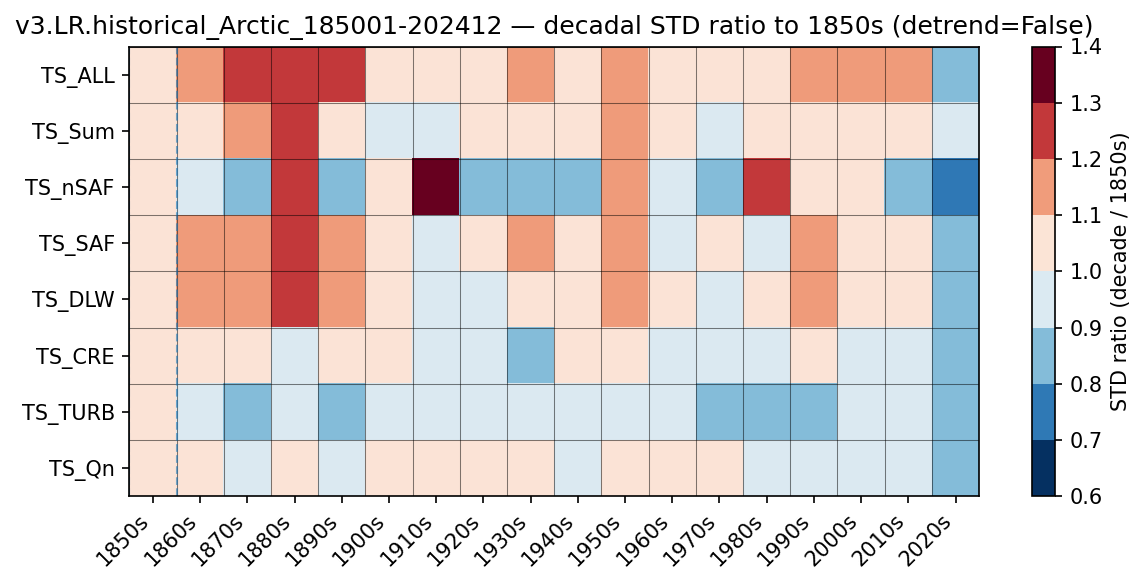

Wrote: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure/Arctic/heatmap_ts_panels_v3.LR.historical_Arctic_185001-202412.pdf


In [4]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    out_path  = str(V3LE_DIAG_DIR)
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Arctic"                 # label only (TS-only analysis)
    dtype      = "climo"
    period     = "185001-202412"          # must match filenames
    prefix     = "v3.LR.historical"
    tail       = "area_mean_ts"
    join_mode  = "exact"                  # robust if some members end early

    # anomaly controls
    anom_type  = "ensemble_mean"          # "ensemble_mean" | "first_year" | "climo_mean"
    base_slice = slice("1850", "1900")    # only used if anom_type == "climo_mean"

    # --- I/O dirs ---
    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    data_path = f"{top_path}/data/{regnam}"

    # --- read ensemble time series (TS-only, dims: ens,time) ---
    reader = ExpDataReader(
        anom_type=anom_type,
        data_dir=data_path,
        regnam=regnam,     # TS-only: region string is just metadata
        dtype=dtype,
        verbose=True,
    )

    # Normalize period for filenames
    _ = reader._normalize_period_str(period)

    ens = reader.read_ensemble_ts(
        prefix=prefix,
        tail=tail,
        period=period,
        join=join_mode,
        validate_annual=True,
    )

    # metadata echo
    tyears = pd.DatetimeIndex(ens["time"].values).year
    print(f"[meta] first 3 years: {tyears[:3].tolist()}  last 3 years: {tyears[-3:].tolist()}")
    print(f"[meta] loaded ensemble sizes: {dict(ens.sizes)}")
    t0 = str(ens["time"].values[0]) if ens.sizes.get("time", 0) else "NA"
    t1 = str(ens["time"].values[-1]) if ens.sizes.get("time", 0) else "NA"
    print(f"[meta] time range: {t0} → {t1}")
    print(f"[meta] variables (first 10): {list(ens.data_vars)[:10]}")

    # --- anomaly selection ---
    if anom_type == "ensemble_mean":
        baseline_kind   = "ensmean"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "first_year":
        baseline_kind   = "first"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "climo_mean":
        baseline_kind   = "mean"
        base_time_slice = base_slice
        verbose_anom    = False
    else:
        raise ValueError(f"Unknown anom_type: {anom_type}")

    # --- compute anomalies (D* vars); keep raw alongside is fine ---
    anom_full = ExpDataReader.to_anomaly(
        ens,
        base_time_slice=base_time_slice,
        baseline_kind=baseline_kind,   # 'ensmean' | 'first' | 'mean'
        vars=None,                     # all variables
        prefix="D",
        verbose=verbose_anom,
        tol=1e-12,
        keep_raw=True,                 # OK; we'll filter to D* for the budget
        drop_existing_prefixed=True,
        prefer_new=True,
    )
    
    # --- compute TS-only budget (no regional ops) ---
    budget = EnsembleTSBudget(
        ens,
        anom_full,                      # contains D* vars; raw fields are ignored
        use_time_varying_factor=True,
        include_residual=True,
        name=f"{prefix}_{regnam}_{period}",
    )
    
    #terms = [t for t in ["TS_ALL","TS_Qn","TS_TURB","TS_CRE","TS_SAF","TS_nSAF","TS_DLW","TS_RESID"] if t in ds_budget],
    terms  = list(Budget_CATALOG.keys())   # e.g., ["TS_ALL","TS_TURB",...,"TS_Sum"]

    # Ratios relative to the earliest decade in your data (default)
    path = budget.plot_decadal_ratio_heatmap(
        terms=terms,
        metric="std",
        detrend=False,
        decades="auto",         # or e.g., [1850,1860,...]
        base_decade=None,       # default = earliest decade
        vmin=0.6,   # lower limit of colorbar
        vmax=1.2,   # upper limit of colorbar
        outdir=fig_dir,
        filename=f"heatmap_ts_panels_{prefix}_{regnam}_{period}.pdf",
        annotate=False,
        symmetric=True,
        show=True
    )
    print("Wrote:", path)
    

[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en00.area_mean_ts.185001-202412.nc
  [ok] member 00 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en01.area_mean_ts.185001-202412.nc
  [ok] member 01 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en02.area_mean_ts.185001-202412.nc
  [ok] member 02 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en03.area_mean_ts.185001-202412.nc
  [ok] member 03 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en04.area_mean_ts.185001-202412.nc
  [ok] member 04 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm

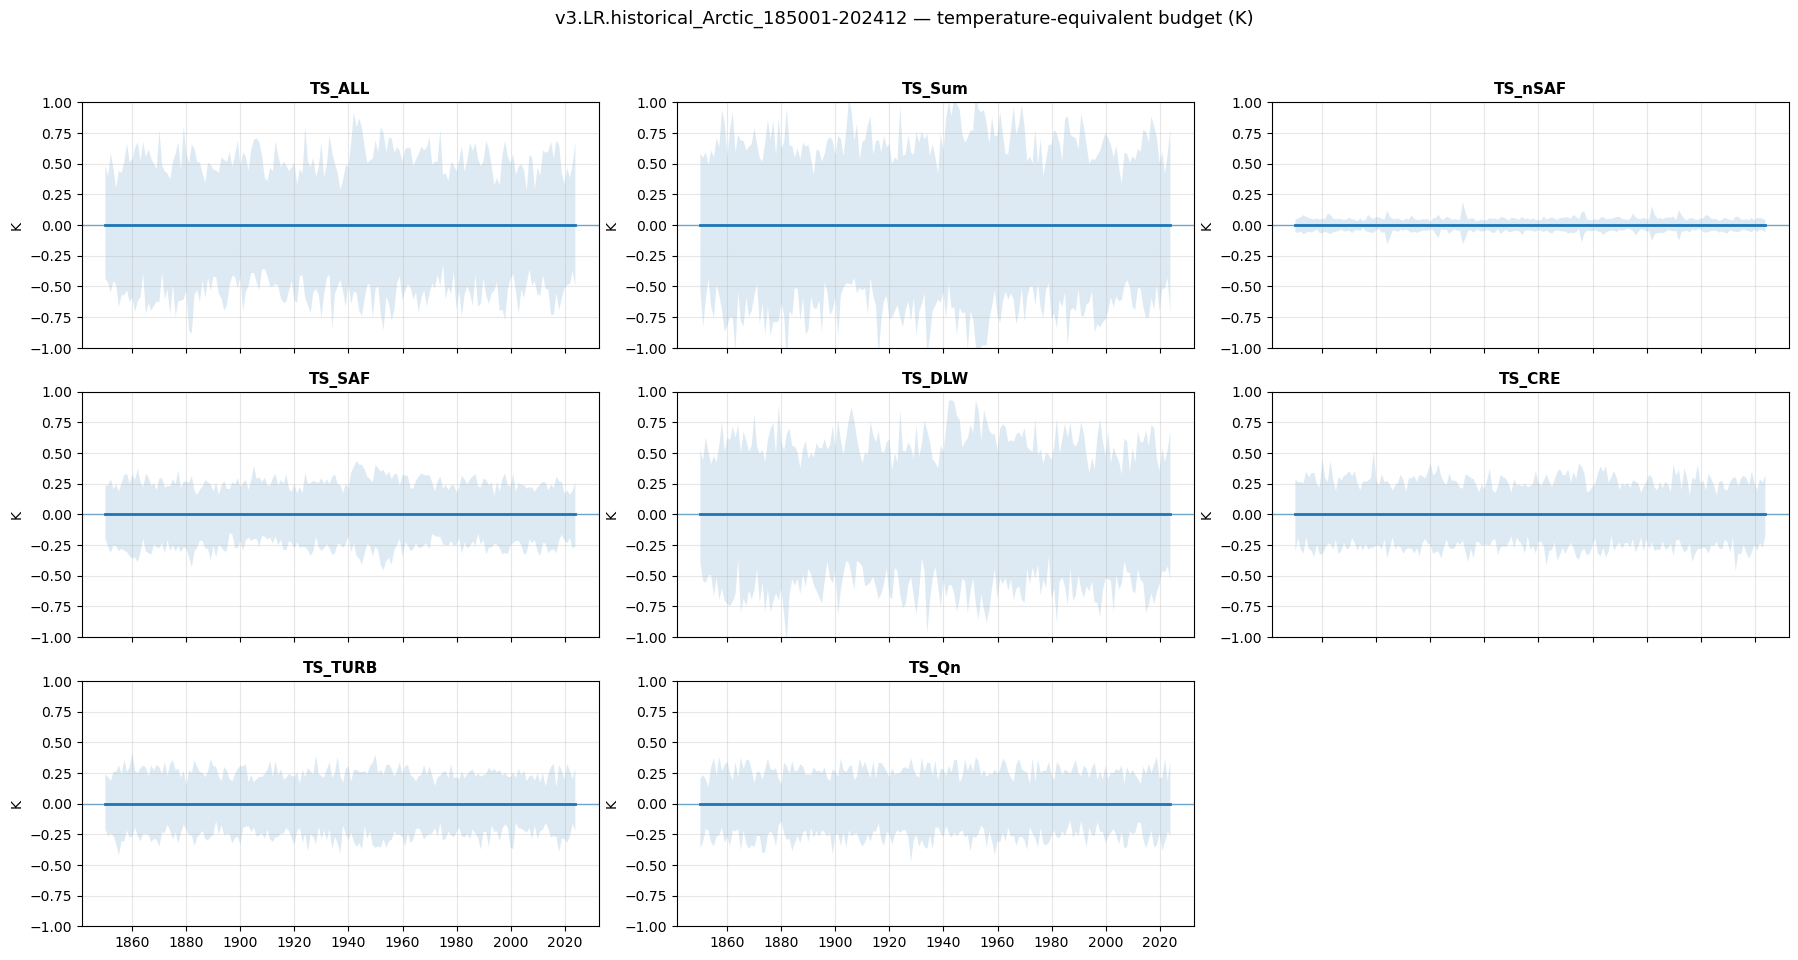

[write] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/figure/Arctic/budget_ts_panels_v3.LR.historical_Arctic_185001-202412.pdf


In [5]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    out_path  = str(V3LE_DIAG_DIR)
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Arctic"                 # label only (TS-only analysis)
    dtype      = "climo"
    period     = "185001-202412"          # must match filenames
    prefix     = "v3.LR.historical"
    tail       = "area_mean_ts"
    join_mode  = "exact"                  # robust if some members end early

    # anomaly controls
    anom_type  = "ensemble_mean"          # "ensemble_mean" | "first_year" | "climo_mean"
    base_slice = slice("1850", "1900")    # only used if anom_type == "climo_mean"

    # --- I/O dirs ---
    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    data_path = f"{top_path}/data/{regnam}"

    # --- read ensemble time series (TS-only, dims: ens,time) ---
    reader = ExpDataReader(
        anom_type=anom_type,
        data_dir=data_path,
        regnam=regnam,     # TS-only: region string is just metadata
        dtype=dtype,
        verbose=True,
    )

    # Normalize period for filenames
    _ = reader._normalize_period_str(period)

    ens = reader.read_ensemble_ts(
        prefix=prefix,
        tail=tail,
        period=period,
        join=join_mode,
        validate_annual=True,
    )

    # metadata echo
    tyears = pd.DatetimeIndex(ens["time"].values).year
    print(f"[meta] first 3 years: {tyears[:3].tolist()}  last 3 years: {tyears[-3:].tolist()}")
    print(f"[meta] loaded ensemble sizes: {dict(ens.sizes)}")
    t0 = str(ens["time"].values[0]) if ens.sizes.get("time", 0) else "NA"
    t1 = str(ens["time"].values[-1]) if ens.sizes.get("time", 0) else "NA"
    print(f"[meta] time range: {t0} → {t1}")
    print(f"[meta] variables (first 10): {list(ens.data_vars)[:10]}")

    # --- anomaly selection ---
    if   anom_type == "ensemble_mean":
        baseline_kind   = "ensmean"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "first_year":
        baseline_kind   = "first"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "climo_mean":
        baseline_kind   = "mean"
        base_time_slice = base_slice
        verbose_anom    = False
    else:
        raise ValueError(f"Unknown anom_type: {anom_type}")

    # --- compute anomalies (D* vars); keep raw alongside is fine ---
    anom_full = ExpDataReader.to_anomaly(
        ens,
        base_time_slice=base_time_slice,
        baseline_kind=baseline_kind,   # 'ensmean' | 'first' | 'mean'
        vars=None,                     # all variables
        prefix="D",
        verbose=verbose_anom,
        tol=1e-12,
        keep_raw=True,                 # OK; we'll filter to D* for the budget
        drop_existing_prefixed=True,
        prefer_new=True,
    )
    
    # --- compute TS-only budget (no regional ops) ---
    budget = EnsembleTSBudget(
        ens,
        anom_full,                      # contains D* vars; raw fields are ignored
        use_time_varying_factor=True,
        include_residual=True,
        name=f"{prefix}_{regnam}_{period}",
    )
    ds_budget = budget.compute()

    # tidy CSV of all members × terms
    df_budget = budget.to_tidy_df(ds_budget)
    csv_all = os.path.join(out_dir, f"budget_ts_{prefix}_{regnam}_{period}.csv")
    df_budget.to_csv(csv_all, index=False)
    print(f"[write] {csv_all}")
    
    #terms = [t for t in ["TS_ALL","TS_Qn","TS_TURB","TS_CRE","TS_SAF","TS_nSAF","TS_DLW","TS_RESID"] if t in ds_budget],
    terms  = list(Budget_CATALOG.keys())   # e.g., ["TS_ALL","TS_TURB",...,"TS_Sum"]

    # ensemble-mean/quantile stats CSV
    df_stats = budget.compute_stats(ds_budget)
    csv_stats = os.path.join(out_dir, f"budget_ts_stats_{prefix}_{regnam}_{period}.csv")
    df_stats.to_csv(csv_stats, index=False)
    print(f"[write] {csv_stats}")

    # --- multi-panel figure: one panel per budget term ---
    figfile = budget.plot_terms(
        ds_budget,
        terms=terms,
        ncols=3,                        # adjust columns to taste
        vmin=-1.0, 
        vmax=1.0,                       # <- uniform y-range for all panels
        include_members=False,          # set True to overlay thin per-member lines
        outdir=fig_dir,
        filename=f"budget_ts_panels_{prefix}_{regnam}_{period}.pdf",
        show=True,
    )
    print(f"[write] {figfile}")

[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en00.area_mean_ts.185001-202412.nc
  [ok] member 00 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en01.area_mean_ts.185001-202412.nc
  [ok] member 01 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en02.area_mean_ts.185001-202412.nc
  [ok] member 02 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en03.area_mean_ts.185001-202412.nc
  [ok] member 03 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en04.area_mean_ts.185001-202412.nc
  [ok] member 04 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm

/tmp/ipykernel_3596751/598201116.py:548: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3596751/598201116.py:548: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3596751/598201116.py:548: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3596751/598201116.py:548: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3596751/598201116.py:548: MatplotlibDeprecationWarning: The 'labels' 

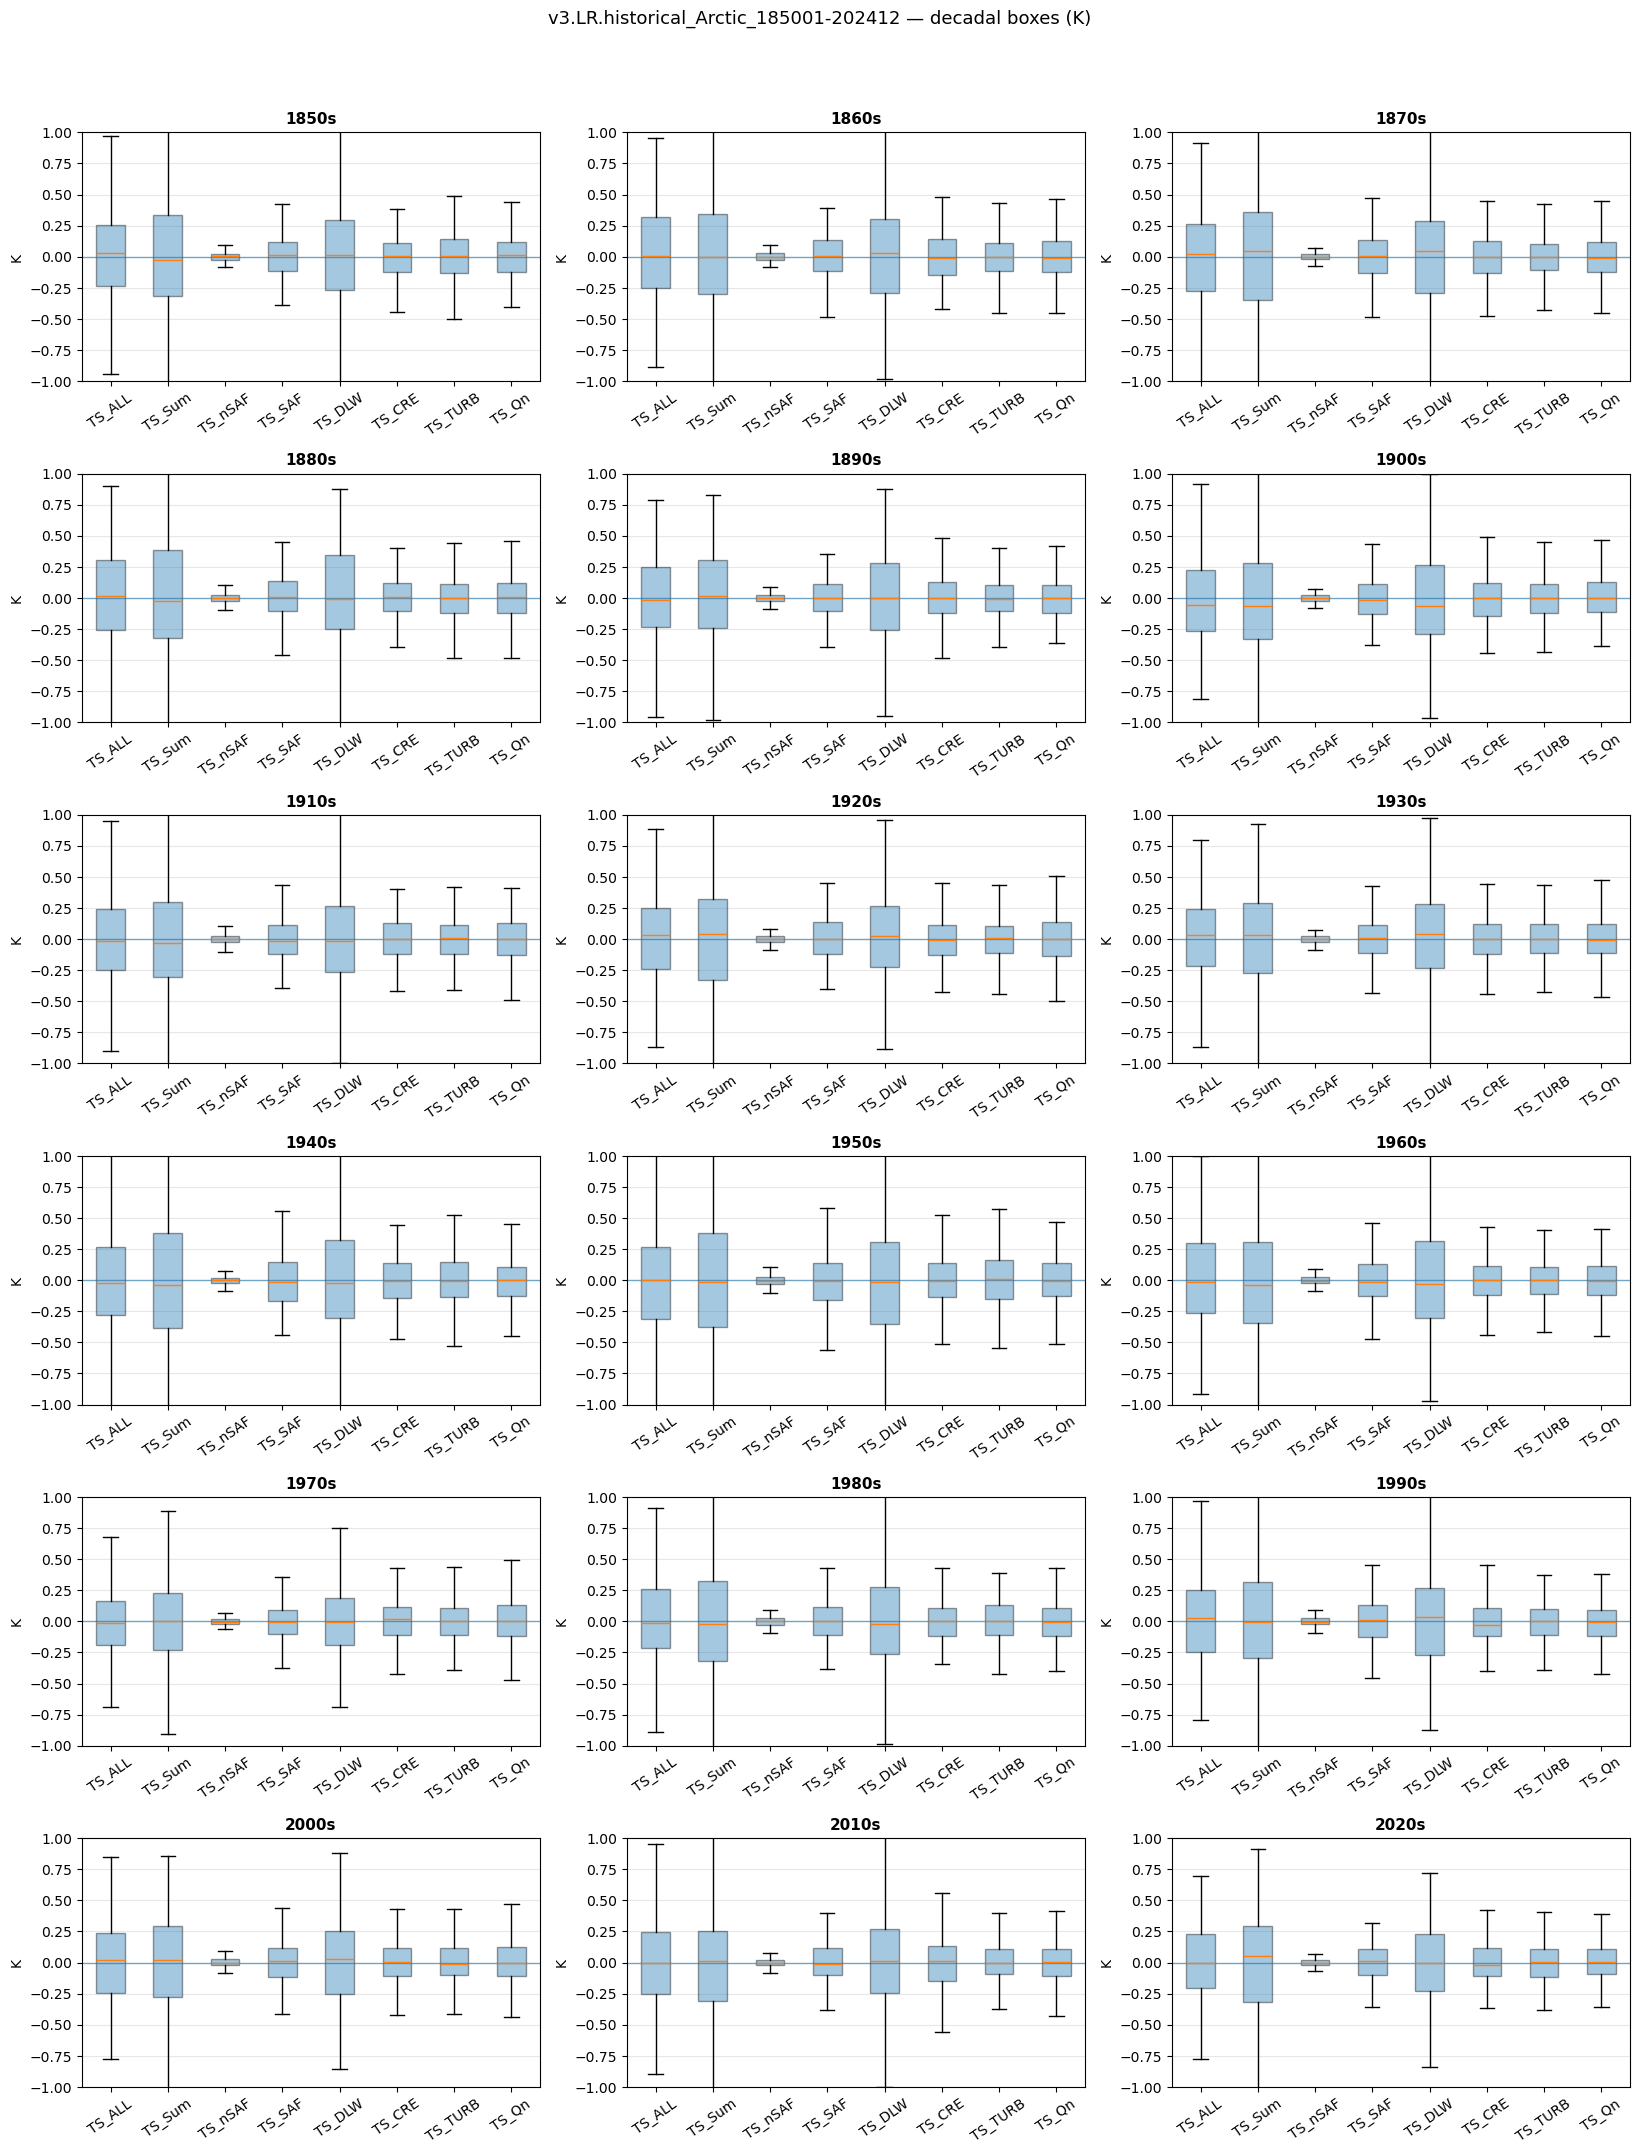

In [6]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    out_path  = str(V3LE_DIAG_DIR)
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Arctic"                 # label only (TS-only analysis)
    dtype      = "climo"
    period     = "185001-202412"          # must match filenames
    prefix     = "v3.LR.historical"
    tail       = "area_mean_ts"
    join_mode  = "exact"                  # robust if some members end early

    # anomaly controls
    anom_type  = "ensemble_mean"          # "ensemble_mean" | "first_year" | "climo_mean"
    base_slice = slice("1850", "1900")    # only used if anom_type == "climo_mean"

    # --- I/O dirs ---
    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    data_path = f"{top_path}/data/{regnam}"

    # --- read ensemble time series (TS-only, dims: ens,time) ---
    reader = ExpDataReader(
        anom_type=anom_type,
        data_dir=data_path,
        regnam=regnam,     # TS-only: region string is just metadata
        dtype=dtype,
        verbose=True,
    )

    # Normalize period for filenames
    _ = reader._normalize_period_str(period)

    ens = reader.read_ensemble_ts(
        prefix=prefix,
        tail=tail,
        period=period,
        join=join_mode,
        validate_annual=True,
    )

    # metadata echo
    tyears = pd.DatetimeIndex(ens["time"].values).year
    print(f"[meta] first 3 years: {tyears[:3].tolist()}  last 3 years: {tyears[-3:].tolist()}")
    print(f"[meta] loaded ensemble sizes: {dict(ens.sizes)}")
    t0 = str(ens["time"].values[0]) if ens.sizes.get("time", 0) else "NA"
    t1 = str(ens["time"].values[-1]) if ens.sizes.get("time", 0) else "NA"
    print(f"[meta] time range: {t0} → {t1}")
    print(f"[meta] variables (first 10): {list(ens.data_vars)[:10]}")

    # --- anomaly selection ---
    if   anom_type == "ensemble_mean":
        baseline_kind   = "ensmean"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "first_year":
        baseline_kind   = "first"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "climo_mean":
        baseline_kind   = "mean"
        base_time_slice = base_slice
        verbose_anom    = False
    else:
        raise ValueError(f"Unknown anom_type: {anom_type}")

    # --- compute anomalies (D* vars); keep raw alongside is fine ---
    anom_full = ExpDataReader.to_anomaly(
        ens,
        base_time_slice=base_time_slice,
        baseline_kind=baseline_kind,   # 'ensmean' | 'first' | 'mean'
        vars=None,                     # all variables
        prefix="D",
        verbose=verbose_anom,
        tol=1e-12,
        keep_raw=True,                 # OK; we'll filter to D* for the budget
        drop_existing_prefixed=True,
        prefer_new=True,
    )
    
    # --- compute TS-only budget (no regional ops) ---
    budget = EnsembleTSBudget(
        ens,
        anom_full,                      # contains D* vars; raw fields are ignored
        use_time_varying_factor=True,
        include_residual=True,
        name=f"{prefix}_{regnam}_{period}",
    )
    ds_budget = budget.compute()

    # tidy CSV of all members × terms
    df_budget = budget.to_tidy_df(ds_budget)
    csv_all = os.path.join(out_dir, f"budget_ts_{prefix}_{regnam}_{period}.csv")
    df_budget.to_csv(csv_all, index=False)
    print(f"[write] {csv_all}")
    
    #terms = [t for t in ["TS_ALL","TS_Qn","TS_TURB","TS_CRE","TS_SAF","TS_nSAF","TS_DLW","TS_RESID"] if t in ds_budget],
    terms  = list(Budget_CATALOG.keys())   # e.g., ["TS_ALL","TS_TURB",...,"TS_Sum"]

    # ensemble-mean/quantile stats CSV
    df_stats = budget.compute_stats(ds_budget)
    csv_stats = os.path.join(out_dir, f"budget_ts_stats_{prefix}_{regnam}_{period}.csv")
    df_stats.to_csv(csv_stats, index=False)
    print(f"[write] {csv_stats}")

    paths = budget.plot_decadal_boxplots(
        ds_budget,
        terms=terms,
        decades="auto",
        separate_figs=False,    # <= one grid figure
        ncols=3,
        vmin=-1.0, vmax=1.0,
        outdir=fig_dir,
        filename_prefix="budget_decade_boxes",
        show = True
    )

[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en00.area_mean_ts.185001-202412.nc
  [ok] member 00 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en01.area_mean_ts.185001-202412.nc
  [ok] member 01 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en02.area_mean_ts.185001-202412.nc
  [ok] member 02 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en03.area_mean_ts.185001-202412.nc
  [ok] member 03 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en04.area_mean_ts.185001-202412.nc
  [ok] member 04 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm

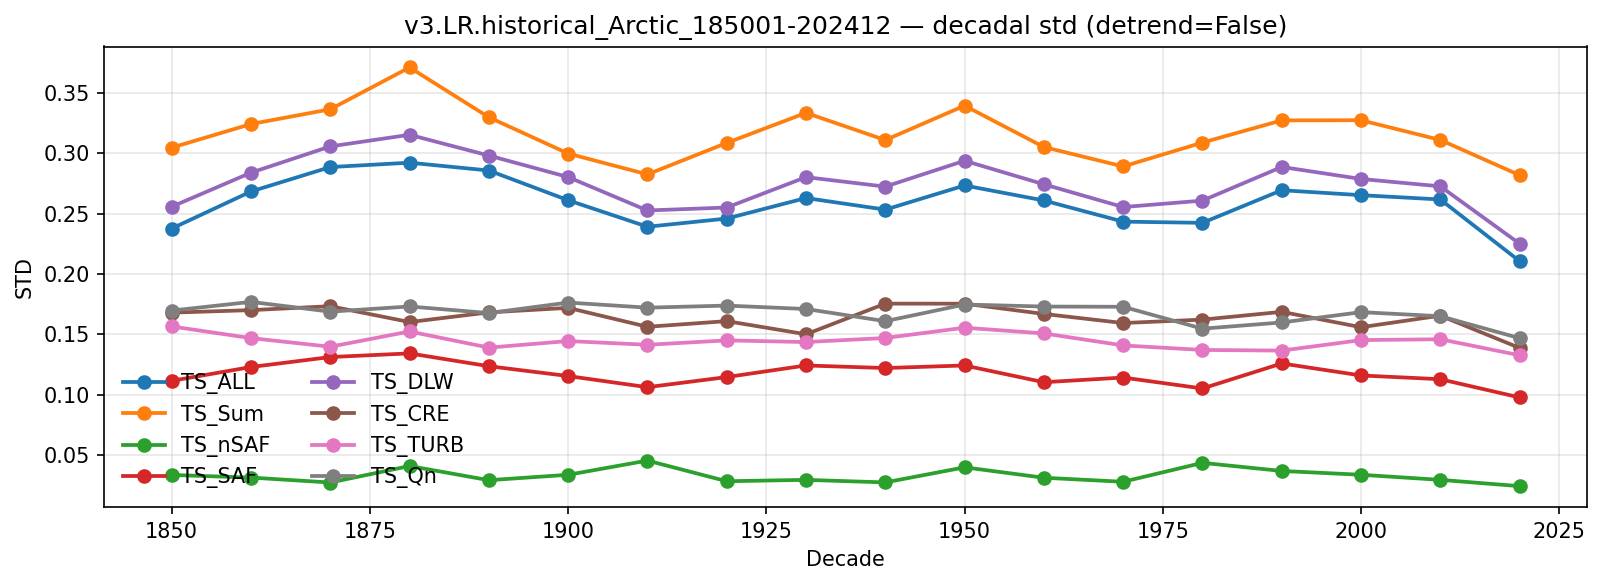

In [7]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    out_path  = str(V3LE_DIAG_DIR)
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Arctic"                 # label only (TS-only analysis)
    dtype      = "climo"
    period     = "185001-202412"          # must match filenames
    prefix     = "v3.LR.historical"
    tail       = "area_mean_ts"
    join_mode  = "exact"                  # robust if some members end early

    # anomaly controls
    anom_type  = "ensemble_mean"          # "ensemble_mean" | "first_year" | "climo_mean"
    base_slice = slice("1850", "1900")    # only used if anom_type == "climo_mean"

    # --- I/O dirs ---
    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    data_path = f"{top_path}/data/{regnam}"

    # --- read ensemble time series (TS-only, dims: ens,time) ---
    reader = ExpDataReader(
        anom_type=anom_type,
        data_dir=data_path,
        regnam=regnam,     # TS-only: region string is just metadata
        dtype=dtype,
        verbose=True,
    )

    # Normalize period for filenames
    _ = reader._normalize_period_str(period)

    ens = reader.read_ensemble_ts(
        prefix=prefix,
        tail=tail,
        period=period,
        join=join_mode,
        validate_annual=True,
    )

    # metadata echo
    tyears = pd.DatetimeIndex(ens["time"].values).year
    print(f"[meta] first 3 years: {tyears[:3].tolist()}  last 3 years: {tyears[-3:].tolist()}")
    print(f"[meta] loaded ensemble sizes: {dict(ens.sizes)}")
    t0 = str(ens["time"].values[0]) if ens.sizes.get("time", 0) else "NA"
    t1 = str(ens["time"].values[-1]) if ens.sizes.get("time", 0) else "NA"
    print(f"[meta] time range: {t0} → {t1}")
    print(f"[meta] variables (first 10): {list(ens.data_vars)[:10]}")

    # --- anomaly selection ---
    if   anom_type == "ensemble_mean":
        baseline_kind   = "ensmean"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "first_year":
        baseline_kind   = "first"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "climo_mean":
        baseline_kind   = "mean"
        base_time_slice = base_slice
        verbose_anom    = False
    else:
        raise ValueError(f"Unknown anom_type: {anom_type}")

    # --- compute anomalies (D* vars); keep raw alongside is fine ---
    anom_full = ExpDataReader.to_anomaly(
        ens,
        base_time_slice=base_time_slice,
        baseline_kind=baseline_kind,   # 'ensmean' | 'first' | 'mean'
        vars=None,                     # all variables
        prefix="D",
        verbose=verbose_anom,
        tol=1e-12,
        keep_raw=True,                 # OK; we'll filter to D* for the budget
        drop_existing_prefixed=True,
        prefer_new=True,
    )
    
    # --- compute TS-only budget (no regional ops) ---
    budget = EnsembleTSBudget(
        ens,
        anom_full,                      # contains D* vars; raw fields are ignored
        use_time_varying_factor=True,
        include_residual=True,
        name=f"{prefix}_{regnam}_{period}",
    )
    # ensemble-mean/quantile stats CSV
    df_dec = budget.compute_decadal_variability(
        terms=terms,
        metric="std",
        detrend=False
    )
    path = budget.plot_decadal_variability(
        terms=terms, 
        metric="std", 
        detrend=False,
        show=True
    )


[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en00.area_mean_ts.185001-202412.nc
  [ok] member 00 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en01.area_mean_ts.185001-202412.nc
  [ok] member 01 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en02.area_mean_ts.185001-202412.nc
  [ok] member 02 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en03.area_mean_ts.185001-202412.nc
  [ok] member 03 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble/data/Arctic/v3.LR.historical.en04.area_mean_ts.185001-202412.nc
  [ok] member 04 sizes: {'ens': 1, 'time': 175}
[ens] loading /lcrc/group/e3sm

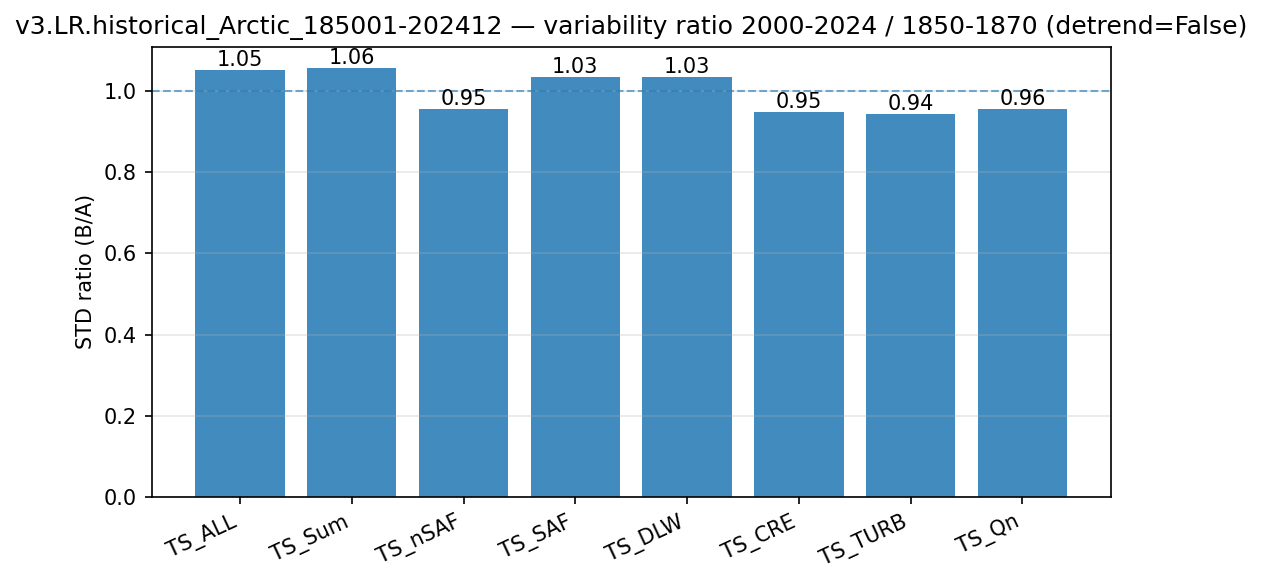

Wrote: figs/variance_ratio_TS_budget.pdf


In [8]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/large_ensemble"
    out_path  = str(V3LE_DIAG_DIR)
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Arctic"                 # label only (TS-only analysis)
    dtype      = "climo"
    period     = "185001-202412"          # must match filenames
    prefix     = "v3.LR.historical"
    tail       = "area_mean_ts"
    join_mode  = "exact"                  # robust if some members end early

    # anomaly controls
    anom_type  = "ensemble_mean"          # "ensemble_mean" | "first_year" | "climo_mean"
    base_slice = slice("1850", "1900")    # only used if anom_type == "climo_mean"

    # --- I/O dirs ---
    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    data_path = f"{top_path}/data/{regnam}"

    # --- read ensemble time series (TS-only, dims: ens,time) ---
    reader = ExpDataReader(
        anom_type=anom_type,
        data_dir=data_path,
        regnam=regnam,     # TS-only: region string is just metadata
        dtype=dtype,
        verbose=True,
    )

    # Normalize period for filenames
    _ = reader._normalize_period_str(period)

    ens = reader.read_ensemble_ts(
        prefix=prefix,
        tail=tail,
        period=period,
        join=join_mode,
        validate_annual=True,
    )

    # metadata echo
    tyears = pd.DatetimeIndex(ens["time"].values).year
    print(f"[meta] first 3 years: {tyears[:3].tolist()}  last 3 years: {tyears[-3:].tolist()}")
    print(f"[meta] loaded ensemble sizes: {dict(ens.sizes)}")
    t0 = str(ens["time"].values[0]) if ens.sizes.get("time", 0) else "NA"
    t1 = str(ens["time"].values[-1]) if ens.sizes.get("time", 0) else "NA"
    print(f"[meta] time range: {t0} → {t1}")
    print(f"[meta] variables (first 10): {list(ens.data_vars)[:10]}")

    # --- anomaly selection ---
    if   anom_type == "ensemble_mean":
        baseline_kind   = "ensmean"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "first_year":
        baseline_kind   = "first"
        base_time_slice = None
        verbose_anom    = False
    elif anom_type == "climo_mean":
        baseline_kind   = "mean"
        base_time_slice = base_slice
        verbose_anom    = False
    else:
        raise ValueError(f"Unknown anom_type: {anom_type}")

    # --- compute anomalies (D* vars); keep raw alongside is fine ---
    anom_full = ExpDataReader.to_anomaly(
        ens,
        base_time_slice=base_time_slice,
        baseline_kind=baseline_kind,   # 'ensmean' | 'first' | 'mean'
        vars=None,                     # all variables
        prefix="D",
        verbose=verbose_anom,
        tol=1e-12,
        keep_raw=True,                 # OK; we'll filter to D* for the budget
        drop_existing_prefixed=True,
        prefer_new=True,
    )
    
    # --- compute TS-only budget (no regional ops) ---
    budget = EnsembleTSBudget(
        ens,
        anom_full,                      # contains D* vars; raw fields are ignored
        use_time_varying_factor=True,
        include_residual=True,
        name=f"{prefix}_{regnam}_{period}",
    )
    # ensemble-mean/quantile stats CSV
    df_dec = budget.compute_variance_ratio(
        terms=terms,
        period_a=(1850,1979), 
        period_b=(1980,2024),
        metric="std",
        detrend=False
    )
    
    rat_path = budget.plot_variance_ratio(
        terms=terms,
        period_a=(1850,1870),
        period_b=(2000,2024),
        metric="std",
        detrend=False,
        outdir=str(FIG_DIR_ROOT),
        filename="variance_ratio_TS_budget.pdf",
        show=True
    )
    print("Wrote:", rat_path)
